# VAR (p): Vectores Autorregresivos

Un VAR es un modelo multivariado de series de tiempo, cuyo objetivo es capturar las relaciones dinámicas entre las series que lo componen. Algunos de sus usos más importantes son el pronóstico, el análisis de la respuesta dinámica a choques, análisis de la contribución de cada variable a las fluctuaciones de cada una de las variables que componen el sistema. 

Ilustraremos el modelo y su aplicación tomando como motivación un problema recurrente de asignación de portafolio. Suponga que usted arma un portafolio con bonos y acciones

\begin{equation}
V=E+hB
\end{equation}

Donde $P$ es el valor del portafolio, $E$ el valor en acciones y $hB$ en bonos. El factor $h$ indica la proporción de bonos a acciones. Si se quiere decidir una posición en bonos que minimice la varianza del portafolio, entonces 

\begin{equation}
h^*=-\dfrac{Cov(E,B)}{Var(B)}
\end{equation}

Si, por ejemplo, $h^*=0.7$, entonces por cada \$1000 en acciones se tiene una posición larga de \$700 en bonos

## VAR(1)

Sea $r_e$ el log retorno en acciones y $r_b$ el log retorno en bonos, podemos plantear el siguiente sistema bivariado

\begin{align}
r_{et}&=b_{10}+b_{12}r_{bt}+\gamma_{11}r_{et-1}+\gamma_{12}r_{bt-1}+\epsilon_{et}\\
r_{bt}&=b_{20}+b_{21}r_{et}+\gamma_{21}r_{et-1}+\gamma_{22}r_{bt-1}+\epsilon_{bt}
\end{align}

donde asumimos que $r_e$ y $r_b$ son estacionarias y $\epsilon_{et}$ y $\epsilon_{bt}$ son ruido blanco. Note que cada variable depende de los valores contemporáneos de la otra variable, así como de un rezago de las dos variables. Este sistema de ecuaciones constituye un VAR(1). Estas ecuaciones no pueden ser estimadas de manera independiente pues los efectos contemporáneos producen correlación de los regresores con el error. El sistema se transforma en lo que se conoce como un VAR estándar

\begin{align}
r_{et}&=a_{10}+a_{11}r_{et-1}+a_{12}r_{bt-1}+u_{1t}\\
r_{bt}&=a_{20}+a_{21}r_{et-1}+a_{22}r_{bt-1}+u_{2t}
\end{align}

En esta nueva formulación, los coeficientes $a$ y los errores están compuestos por los coeficientes y los errores del modelo estructural y los coeficientes $b$. Por lo tanto, los choques del VAR estándar no permiten capturar el efecto de los choques $\epsilon$ sobre las variables. Sin embargo, esta formulación sí es estimable y puede ser utilizada para pronosticar. Veamos

### Datos

Usaremos datos diarios del índice MSCI COLCAP y los TES a 5 años. Para estos últimos usamos la tasa cero cupón y a partir de ella inferimos el precio del bono, para luego calcular los retornos. Los datos del MSCI COLCAP provienen de Yahoo Finance y los datos de los TES cero cupón a 5 años del Banco de la República

In [1]:
# ---- 0. Paquetes ------------------------------------------------------------
paquetes <- c("quantmod", "vars", "urca", "tseries", "dplyr",
              "readr", "zoo", "ggplot2", "tidyr")
instalar <- paquetes[!(paquetes %in% installed.packages()[, "Package"])]
if (length(instalar) > 0) install.packages(instalar)
invisible(lapply(paquetes, library, character.only = TRUE))

Loading required package: xts
Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: TTR
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 
Loading required package: MASS
Loading required package: strucchange
Loading required package: sandwich
Loading required package: urca
Loading required package: lmtest

    ‘tseries’ version: 0.10-63

    ‘tseries’ is a package for time series analysis and computational finance.

    See ‘library(help="tseries")’ for details.


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.

Warning messages:
1: package ‘quantmod’ was built under R version 4.5.3 
2: package ‘xts’ was built under R version 4.5.3 
3: package ‘TTR’ was built under R version 4.5.3 
4: package ‘vars’ was built under R version 4.5.3 
5: package ‘strucchange’ was built under R version 4.5.3 
6: package ‘urca’ was built under R version 4.5.3 
7: package ‘tseries’ was built under R version 4.5.3 
8: package ‘dplyr’ was built under R version 4.5.3 


In [3]:
# ==============================================================================
# 1. DESCARGA DE DATOS
# ==============================================================================

# --- 1a. Equity: ETF iShares MSCI COLCAP (ICOLCAP.CL) vía Yahoo Finance ------
fecha_inicio <- "2020-01-01"
fecha_fin    <- Sys.Date()

getSymbols("ICOLCAP.CL", src = "yahoo",
           from = fecha_inicio, to = fecha_fin, auto.assign = TRUE)

equity_px <- Cl(ICOLCAP.CL)                # precio de cierre
colnames(equity_px) <- "px_equity"

# --- 1b. Renta fija: TES en pesos a 5 años, tasa cero cupón ------------------------------------------------------
ruta_tes <- "https://raw.githubusercontent.com/andvarga-eco/econometrics_finance/refs/heads/main/notebooks/1_Tasa_cero_cupon_iqy.csv"   # <-- ajustar ruta al archivo descargado

tes_raw <- read_csv(ruta_tes, locale = locale(decimal_mark = ","))
names(tes_raw)[5]<-"fecha"
tes_raw <- tes_raw|>arrange(fecha)|>filter(Denominación=="Pesos colombianos" & Plazo=="Cinco años")
tes_raw<-tes_raw|>select(c(fecha,'Tasa (%)'))
tes_raw<-tes_raw|>filter(fecha>'2020-01-01')


Warning message:
ICOLCAP.CL contains missing values. Some functions will not work if objects contain missing values in the middle of the series. Consider using na.omit(), na.approx(), na.fill(), etc to remove or replace them. 


Rows: 32932 Columns: 6
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): Fecha sistema, Denominación, Tasa (%), Plazo
dbl  (1): Orden_Plazo
dttm (1): Fecha (dd/mm/aaaa)

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Para convertir la tasa decro cupón a precio usamos la siguiente conversión

\begin{equation*}
P_t=\dfrac{100}{(1+z_t)^{\tau/365}}
\end{equation*}

Donde $z_t$ es la tasa cero cupón observada en el día $t$ para el plazo $\tau$

In [4]:
# Conversión de la tasa cero cupón a precio

plazo_dias <- 1825   # plazo constante en días (1825 = 5 años); ajustar al nodo de curva usado
names(tes_raw)[2]<-"z_tasa"
tes_raw$z_tasa<-as.numeric(tes_raw$z_tasa)
tes_raw <- tes_raw |>
  mutate(
    precio_tes = 100 / (1 + z_tasa)^(plazo_dias / 365),
    ret_bond   = log(precio_tes / lag(precio_tes)) * 100  # rendimiento log, en % (misma escala que equity)
  )


In [5]:
# ==============================================================================
# 2. CONSTRUCCIÓN DEL PANEL DE RENDIMIENTOS
# ==============================================================================

equity_df <- data.frame(fecha = index(equity_px),
                         px_equity = as.numeric(equity_px)) %>%
  mutate(ret_equity = log(px_equity / lag(px_equity)) * 100) %>%
  select(fecha, ret_equity)

tes_df <- tes_raw %>%
  select(fecha, ret_bond)

# Unión por fecha común (alinea calendarios BVC vs. mercado de deuda)
panel <- inner_join(equity_df, tes_df, by = "fecha") %>%
  filter(!is.na(ret_equity), !is.na(ret_bond)) %>%
  arrange(fecha)

cat("Observaciones en el panel alineado:", nrow(panel), "\n")
head(panel)


Observaciones en el panel alineado: 1494 


       fecha ret_equity   ret_bond
1 2020-01-03  0.8263408 -2.1887639
2 2020-01-08 -0.5401729  6.2186623
3 2020-01-09 -0.8277723  3.7552849
4 2020-01-10  0.7205784  3.4847269
5 2020-01-13  0.0000000 -2.7083504
6 2020-01-14 -0.3312398 -0.1255894

Hacemos una visualización gráfica de las series en log precio y retornos

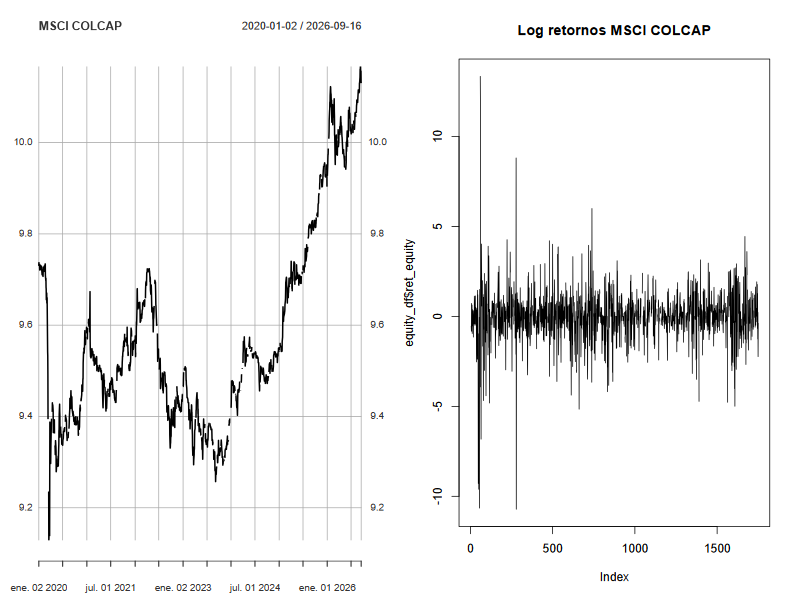

Warning message:
In plot.xy(xy, type, ...) :
  plot type 'line' will be truncated to first character


In [6]:
par(mfrow=c(1,2))
plot(log(equity_px), main="MSCI COLCAP")
plot(equity_df$ret_equity, type="line", main="Log retornos MSCI COLCAP")
par(mfrow=c(1,1))

Warning message:
In plot.xy(xy, type, ...) :
  plot type 'line' will be truncated to first character


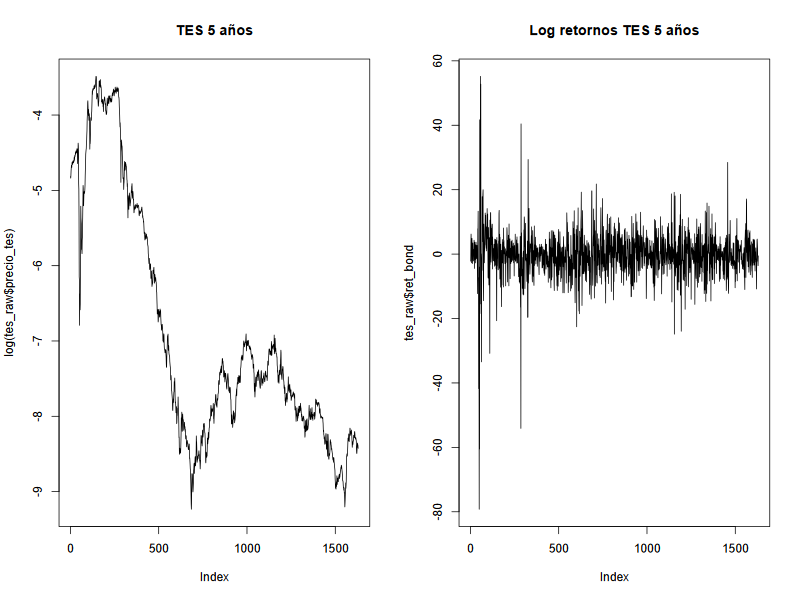

Warning message:
In plot.xy(xy, type, ...) :
  plot type 'line' will be truncated to first character


In [7]:
par(mfrow=c(1,2))
plot(log(tes_raw$precio_tes), type="line", main="TES 5 años")
plot(tes_raw$ret_bond, type="line", main="Log retornos TES 5 años")
par(mfrow=c(1,1))

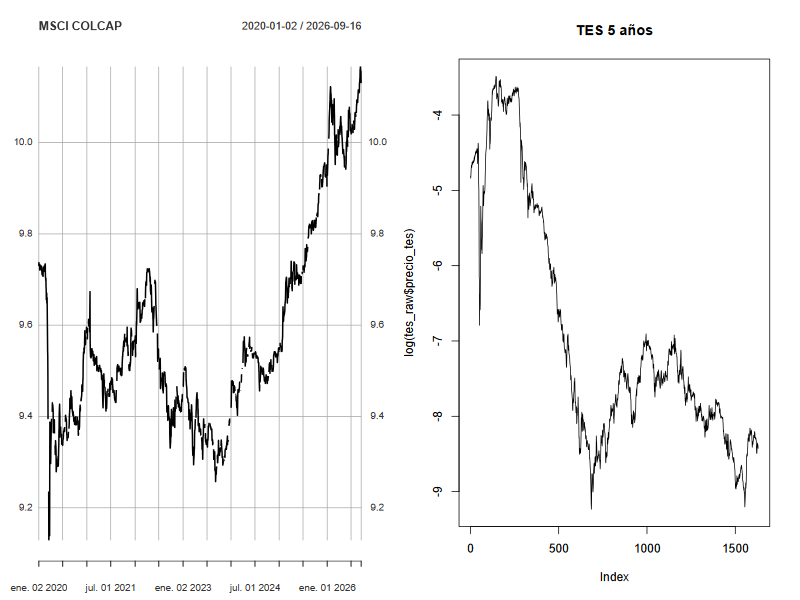

Warning message:
In plot.xy(xy, type, ...) :
  plot type 'line' will be truncated to first character


In [8]:
par(mfrow=c(1,2))
plot(log(equity_px), main="MSCI COLCAP")
plot(log(tes_raw$precio_tes), type="line", main="TES 5 años")
par(mfrow=c(1,1))

### Pruebas de estacionariedad

Debemos asegurarnos que nuestras variables son estacionarias. Usamos la prueba ADF, cuya $H_0$ es que el proceso tiene raíz unitaria (no estacionario). Si rechazamos la nula concluimos que el proceso es estacionario y podemos seguir adelante


In [9]:
# ==============================================================================
# 3. PRUEBAS DE ESTACIONARIEDAD (ADF)
# ==============================================================================

adf_equity <- ur.df(panel$ret_equity, type = "drift", selectlags = "AIC")
adf_bond   <- ur.df(panel$ret_bond,   type = "drift", selectlags = "AIC")

cat("\n--- ADF: ret_equity ---\n"); print(summary(adf_equity))
cat("\n--- ADF: ret_bond ---\n");   print(summary(adf_bond))
# Si el estadístico tau es más negativo que el valor crítico al 5%, se rechaza
# la raíz unitaria -> la serie es estacionaria y se puede usar el VAR en niveles.


--- ADF: ret_equity ---

############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.0840  -0.5215   0.0038   0.6041  13.2083 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.01601    0.03619   0.442   0.6583    
z.lag.1     -0.88062    0.03548 -24.818   <2e-16 ***
z.diff.lag  -0.06424    0.02587  -2.483   0.0131 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.398 on 1489 degrees of freedom
Multiple R-squared:  0.4726,	Adjusted R-squared:  0.4719 
F-statistic: 667.1 on 2 and 1489 DF,  p-value: < 2.2e-16


Value of test-statistic is: -24.8178 307.9616 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.43 -2.86 -2.57
phi1  6.43  4.59  3.78


--- ADF: ret_bon

En ambios casos el valor de la estadística $\tau$ excede  en valor absoluto los valores críticos al 5\% y por lo tanto rechazamos la nula de no estacionario

### Selección del número de rezagos p

Ahora debemos seleccionar el orden p, es decir, cuántos rezagos incluir. Acá lo importante es que sean suficientes rezagos para capturar la dinámica, pero sin que sea un modelo demasiado complejo. Una forma de decidir es usando criterios de información, tales como AIC, BIC. El principio subyacente es escoger un modelo que tenga buen balance entre simplicidad y ajuste. En términos prácticos, se escoge el modelo con menor valor en el critero de información y después se revisa si los residuales presentan autocorrelación

In [10]:
datos_var <- panel %>% select(ret_equity, ret_bond)

seleccion <- VARselect(datos_var, lag.max = 10, type = "const")
print(seleccion$selection)



AIC(n)  HQ(n)  SC(n) FPE(n) 
     6      2      1      6 


El critero AIC tiene siempre a sugerir modelos más grandes, mientras que SC (BIC) más pequeños. HQ se sitúa en el medio. Podríamos usar 2 rezagos y si los residuales no tienen autocorrelación, seguimos con ese modelo. En caso contrario, agregamos más rezagos

In [11]:
p_optimo <- seleccion$selection["HQ(n)"]

modelo_var <- VAR(datos_var, p = p_optimo, type = "const")

serial.test(modelo_var,lags.bg = 5,type="BG")




	Breusch-Godfrey LM test

data:  Residuals of VAR object modelo_var
Chi-squared = 57.707, df = 20, p-value = 1.603e-05


In [12]:
serial.test(modelo_var,lags.pt=10,type="PT.asymptotic")


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object modelo_var
Chi-squared = 75.755, df = 32, p-value = 2.077e-05


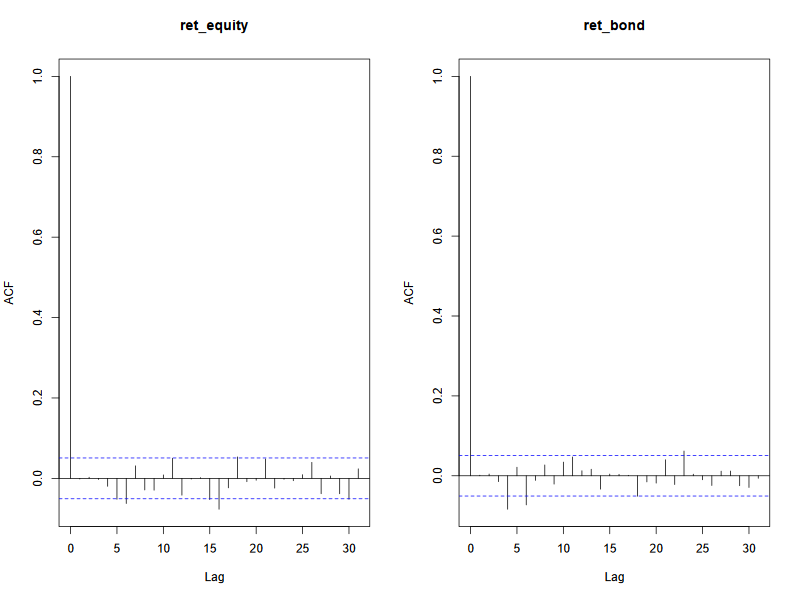

In [13]:
res_var<-as.data.frame(residuals(modelo_var))
par(mfrow=c(1,2))
acf(res_var[1])
acf(res_var[2])
par(mfrow=c(1,1))

Note que tanto los test de autocorrelación como la ACF señalan que los residuales presentan autocorrelación, en especial para los bonos. Ampliamos el modelo al número de rezagos sugerido por AIC

In [14]:
p_optimo <- seleccion$selection["AIC(n)"]

modelo_var <- VAR(datos_var, p = p_optimo, type = "const")

serial.test(modelo_var,lags.bg = 5,type="BG")


	Breusch-Godfrey LM test

data:  Residuals of VAR object modelo_var
Chi-squared = 24.911, df = 20, p-value = 0.2049


In [15]:
serial.test(modelo_var,lags.pt=10,type="PT.asymptotic")


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object modelo_var
Chi-squared = 17.165, df = 16, p-value = 0.375


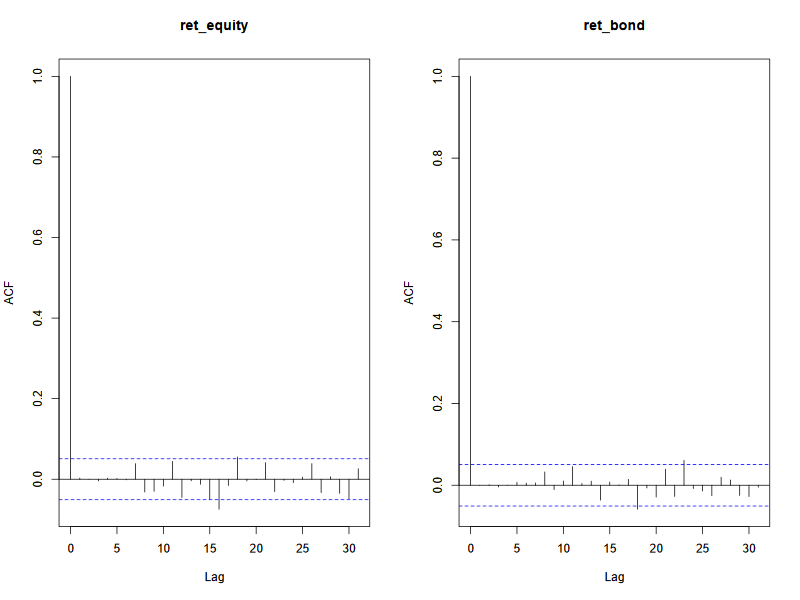

In [16]:
res_var<-as.data.frame(residuals(modelo_var))
par(mfrow=c(1,2))
acf(res_var[1])
acf(res_var[2])
par(mfrow=c(1,1))

Los residuales ya no exhiben autocorrelación. Veamos los resultados de la estimación

In [17]:
summary(modelo_var)


VAR Estimation Results:
Endogenous variables: ret_equity, ret_bond 
Deterministic variables: const 
Sample size: 1488 
Log Likelihood: -7498.241 
Roots of the characteristic polynomial:
0.7487 0.7487 0.7141 0.7141 0.6205 0.6205 0.5588 0.5588 0.5339 0.3324 0.3324 0.274
Call:
VAR(y = datos_var, p = p_optimo, type = "const")


Estimation results for equation ret_equity: 
ret_equity = ret_equity.l1 + ret_bond.l1 + ret_equity.l2 + ret_bond.l2 + ret_equity.l3 + ret_bond.l3 + ret_equity.l4 + ret_bond.l4 + ret_equity.l5 + ret_bond.l5 + ret_equity.l6 + ret_bond.l6 + const 

                Estimate Std. Error t value Pr(>|t|)    
ret_equity.l1  0.0415946  0.0267338   1.556 0.119951    
ret_bond.l1    0.0034300  0.0054824   0.626 0.531653    
ret_equity.l2  0.0441261  0.0267573   1.649 0.099335 .  
ret_bond.l2    0.0151413  0.0054912   2.757 0.005899 ** 
ret_equity.l3 -0.0068588  0.0267814  -0.256 0.797908    
ret_bond.l3    0.0056361  0.0054752   1.029 0.303462    
ret_equity.l4 -0.0219606  0.

Con la matriz de varianzas y covarianzas podemos calcular la correlación contemporánea de las innovaciones, que es cercana a la correlación de los retornos

In [ ]:
2.323/(1.921*46.074)^0.5

In [ ]:
cor(datos_var$ret_equity,datos_var$ret_bond)

### Pronóstico

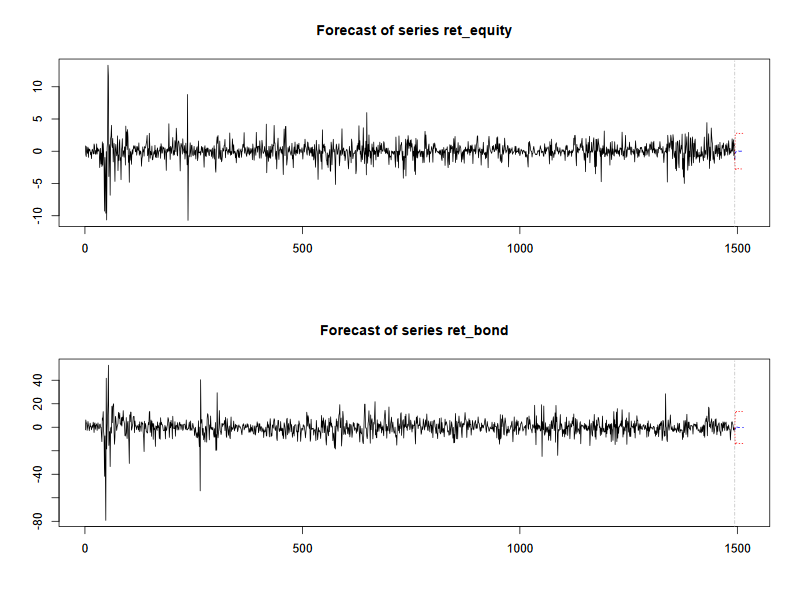

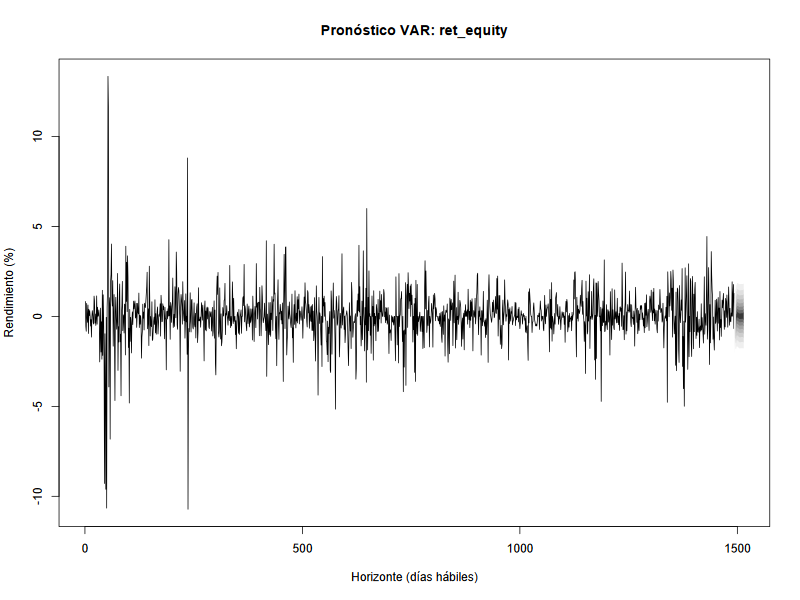

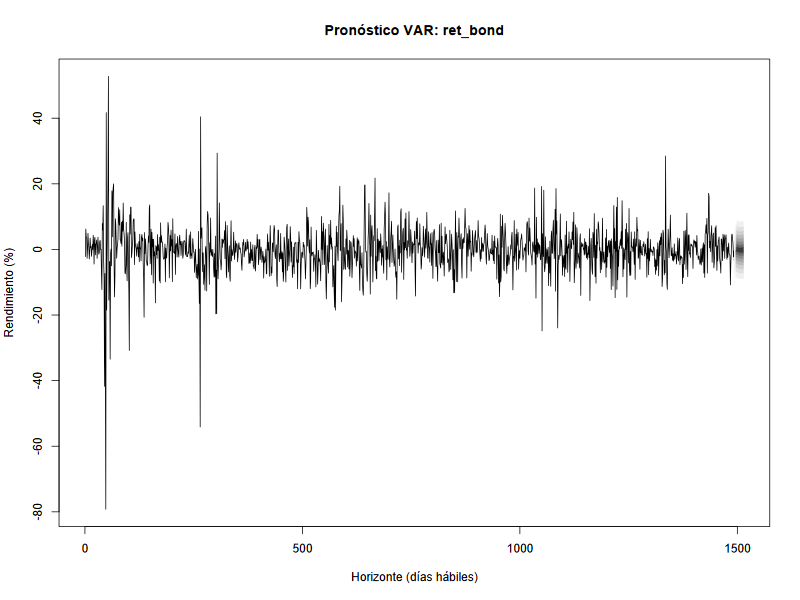

In [18]:
# ==============================================================================
# 4b. PRONÓSTICO (out-of-sample) CON BANDAS DE CONFIANZA
# ==============================================================================
 
horizonte_pronostico <- 20   # días hábiles a pronosticar
 
pronostico <- predict(modelo_var, n.ahead = horizonte_pronostico, ci = 0.95)
 
# --- Gráfico nativo del paquete vars (una figura por variable, con fan chart)
plot(pronostico)
 
# --- Gráfico individual por variable (más control) ---------------------------
fanchart(pronostico, names = "ret_equity",
         main = "Pronóstico VAR: ret_equity",
         xlab = "Horizonte (días hábiles)", ylab = "Rendimiento (%)")
 
fanchart(pronostico, names = "ret_bond",
         main = "Pronóstico VAR: ret_bond",
         xlab = "Horizonte (días hábiles)", ylab = "Rendimiento (%)")
 


Similar a los modelos ARMA, el pronóstico converge a la media de largo plazo de cada serie

### Causalidad de Granger

Decimos que una variable ${X_t}$ no causa en el sentido de Granger a la variable ${Y_t}$ si y solo si ${X_t}$ no mejora el desempeño predictivo de ${Y_t}$. Es una prueba de no significancia conjunta de los coeficientes de los rezagos de ${X_t}$ 

In [ ]:
# ==============================================================================
# 5. CAUSALIDAD DE GRANGER
# ==============================================================================

causalidad_eq_a_bond <- causality(modelo_var, cause = "ret_equity")
causalidad_bond_a_eq <- causality(modelo_var, cause = "ret_bond")

cat("\n--- Granger: equity -> bond ---\n")
print(causalidad_eq_a_bond$Granger)
cat("\n--- Granger: bond -> equity ---\n")
print(causalidad_bond_a_eq$Granger)

En ambos casos rechazamos la nula, luego tenemos evidencia de que los dos procesos mantienen una relación bidireccional

### Impulso respuesta

Ahora queremos saber como un choque sobre una de las variables se transmite y a la otra variable. Para ello debemos identificar el modelo. Recuerde que pasamos del VAR estructural al VAR estándar para poder estimar. Ahora debemos colocar alguna restricción para recuperar las innovaciones estructurales, $\epsilon$, y de esta manera poder responder nuestra pregunta. Una manera de hacerlo es usando un ordenamiento de variables por exogeneidad contemporánea. Por ejemplo, asumo que el retorno de los bonos no afecta contemporáneamente a al de las acciones, pero el de las acciones si afecta contemporáneamente al de los bonos. Las acciones entonces son más exógenas. El criterio de ordenamiento debe informarse por la teoría, la evidencia o la experiencia. Es una decisión

In [19]:
# ==============================================================================
# 6. FUNCIONES IMPULSO-RESPUESTA (IRF) Y FEVD
# ==============================================================================


irf_eb <- irf(modelo_var, impulse = "ret_equity", response = "ret_bond",
                      n.ahead = 10, boot = TRUE, ci = 0.95)
irf_ee<-irf(modelo_var, impulse = "ret_equity", response = "ret_equity",
                      n.ahead = 10, boot = TRUE, ci = 0.95)
irf_be <- irf(modelo_var, impulse = "ret_bond", response = "ret_equity",
                      n.ahead = 10, boot = TRUE, ci = 0.95)
irf_bb<-irf(modelo_var, impulse = "ret_bond", response = "ret_bond",
                      n.ahead = 10, boot = TRUE, ci = 0.95)


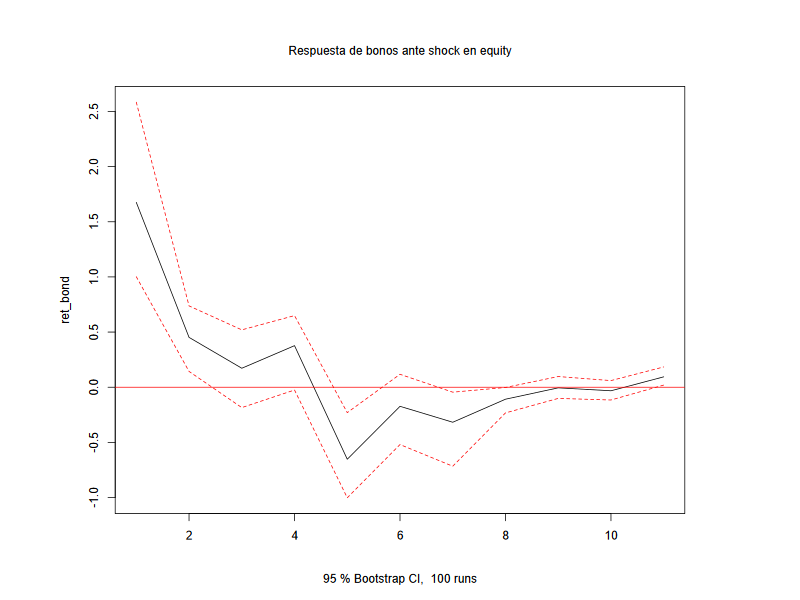

In [20]:
plot(irf_eb, main = "Respuesta de bonos ante shock en equity")

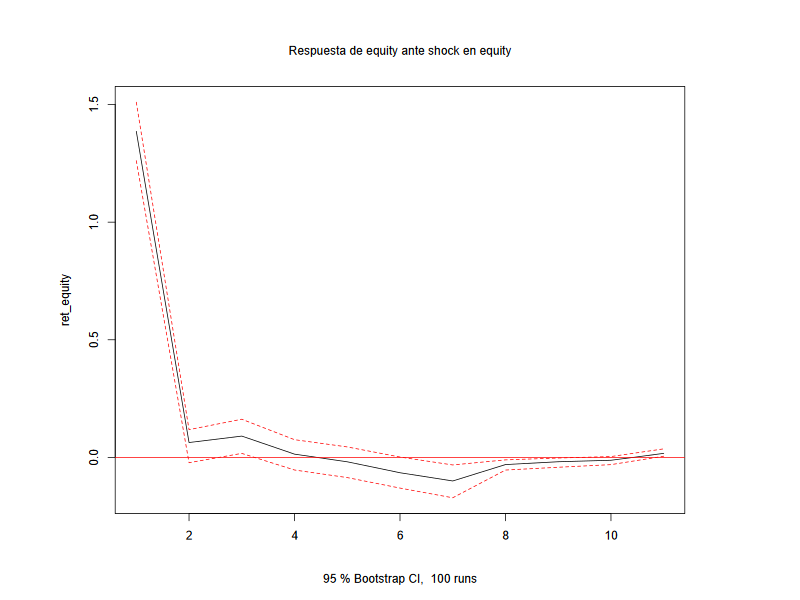

In [21]:
plot(irf_ee, main = "Respuesta de equity ante shock en equity")

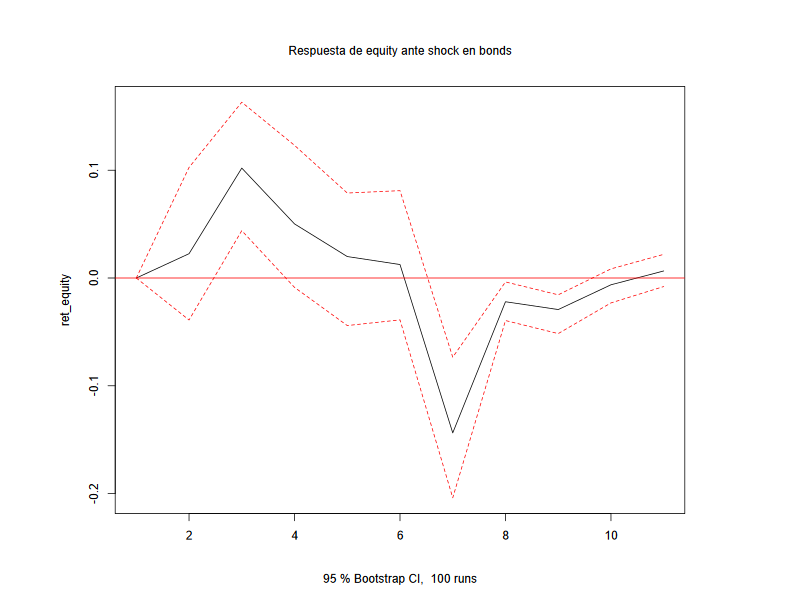

In [22]:
plot(irf_be, main = "Respuesta de equity ante shock en bonds")

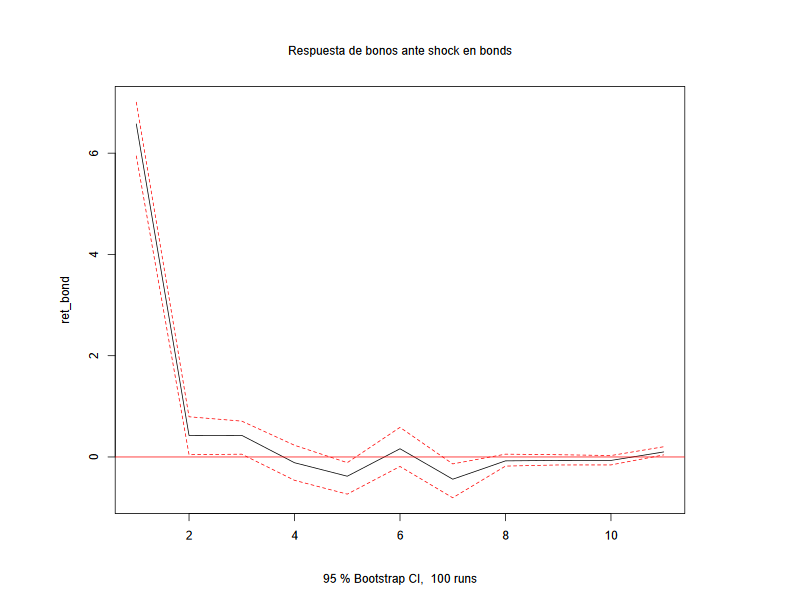

In [23]:
plot(irf_bb, main = "Respuesta de bonos ante shock en bonds")


Como se observa, los choques sobre las acciones tienen un efecto más fuerte sobre los bonos

## Cobertura usando los resultados

In [25]:

# ==============================================================================
# 7. COBERTURA ESTÁTICA (mínima varianza, todo el periodo)
# ==============================================================================

Sigma_hat <- summary(modelo_var)$covres   # matriz de covarianza de residuos
cov_eq_bond <- Sigma_hat["ret_equity", "ret_bond"]
var_bond    <- Sigma_hat["ret_bond", "ret_bond"]
var_eq      <- Sigma_hat["ret_equity", "ret_equity"]

h_static <- -cov_eq_bond / var_bond
cat(sprintf("\nRatio de cobertura estático h* = %.4f\n", h_static))

var_hedged <- var_eq + h_static^2 * var_bond + 2 * h_static * cov_eq_bond
reduccion  <- 1 - var_hedged / var_eq
cat(sprintf("Reducción de varianza con cobertura estática: %.1f%%\n", reduccion * 100))



Ratio de cobertura estático h* = -0.0504
Reducción de varianza con cobertura estática: 6.1%


Note que la covarianza entre bonos y acciones es positiva, luego para reducir la varianza es mejor tomar una posición corta en bonos. Note que usamos la correlación de los residuales para establecer la varianza y la covarianza. Esto es así, porque los residuales son la parte impredecible del retorno, luego buscamos reducir la varianza de la parte que no podemos preveer

### Cobertura dinámica

Ya que tenemos claro el funcionamiento del modelo VAR, podríamos usarlo para definir una estretegia de cobertura dinámica. Esto en últimas parte de la premisa de que la correlación entre los dos activos no es estable en el tiempo. El flujo de trabajo siguiente lo que hace es reestimar un modelo VAR(1) cada 20 días usando una ventana de observación de 100 días. 

In [26]:
# ==============================================================================
# 8. COBERTURA DINÁMICA (VAR en ventana móvil)
# ==============================================================================

ventana <- 100   # días por ventana
paso    <- 20    # frecuencia de reestimación

n <- nrow(datos_var)
resultados_h <- data.frame()

for (inicio in seq(1, n - ventana, by = paso)) {
  fin <- inicio + ventana - 1
  sub_datos <- datos_var[inicio:fin, ]

  modelo_sub <- tryCatch(
    VAR(sub_datos, p = 1, type = "const"),
    error = function(e) NULL
  )
  if (is.null(modelo_sub)) next

  S <- summary(modelo_sub)$covres
  h_t <- -S["ret_equity", "ret_bond"] / S["ret_bond", "ret_bond"]

  resultados_h <- rbind(resultados_h,
                         data.frame(fecha_fin = panel$fecha[fin], h_t = h_t))
}



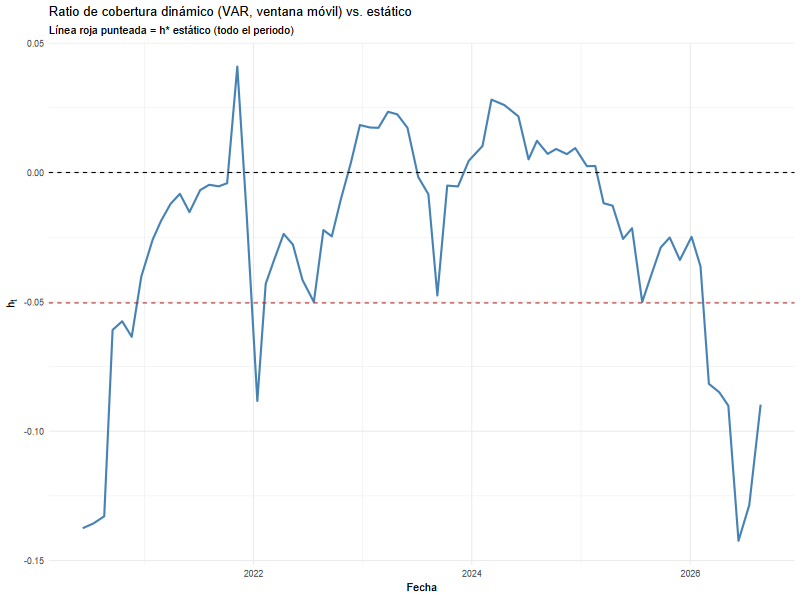

In [27]:
# Gráfico del ratio de cobertura dinámico en el tiempo
ggplot(resultados_h, aes(x = fecha_fin, y = h_t)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_hline(yintercept = h_static, linetype = "dashed", color = "firebrick") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
    labs(title = "Ratio de cobertura dinámico (VAR, ventana móvil) vs. estático",
       subtitle = "Línea roja punteada = h* estático (todo el periodo)",
       x = "Fecha", y = expression(h[t])) +
  theme_minimal()

Ahora, dado que el propósito es reducir la volatilidad del portafolio, entonces revisamos como se habría comportado el portafolio sin cobertura, es decir solo equity, con cobertura estática y con cobertura dinámica

In [28]:
# ==============================================================================
# 9. COMPARACIÓN DE PnL: SIN COBERTURA vs. ESTÁTICA vs. DINÁMICA
# ==============================================================================

posicion_equity <- 1e6   # COP o USD, según la serie usada

pnl_sin <- c(); pnl_est <- c(); pnl_din <- c()

for (i in seq_len(nrow(resultados_h))) {
  idx_fin <- which(panel$fecha == resultados_h$fecha_fin[i])
  idx_ini <- idx_fin + 1
  idx_last <- min(idx_fin + paso, n)
  if (idx_ini > idx_last) next

  bloque <- datos_var[idx_ini:idx_last, ]
  h_t <- resultados_h$h_t[i]

  pnl_sin <- c(pnl_sin, posicion_equity * bloque$ret_equity / 100)
  pnl_est <- c(pnl_est, posicion_equity * bloque$ret_equity / 100 +
                 h_static * posicion_equity * bloque$ret_bond / 100)
  pnl_din <- c(pnl_din, posicion_equity * bloque$ret_equity / 100 +
                 h_t * posicion_equity * bloque$ret_bond / 100)
}

cat(sprintf("\nVolatilidad PnL SIN cobertura:     %s\n", format(sd(pnl_sin), big.mark = ",")))
cat(sprintf("Volatilidad PnL cobertura ESTÁTICA: %s (reducción %.1f%%)\n",
            format(sd(pnl_est), big.mark = ","), (1 - sd(pnl_est)/sd(pnl_sin)) * 100))
cat(sprintf("Volatilidad PnL cobertura DINÁMICA: %s (reducción %.1f%%)\n",
            format(sd(pnl_din), big.mark = ","), (1 - sd(pnl_din)/sd(pnl_sin)) * 100))


Volatilidad PnL SIN cobertura:     12,098.77
Volatilidad PnL cobertura ESTÁTICA: 12,204.26 (reducción -0.9%)
Volatilidad PnL cobertura DINÁMICA: 12,112.49 (reducción -0.1%)
